## Figure 2 {q, p} phase space plot corresponding to different energy levels.

In [1]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS

config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture.weights.h5")

initial_state = np.zeros(2)

timegrad_fn = utils.get_timegrad_fn(functions.functions("1D_Gauss_mix"))
states_numgrad, states_lhnn = [], []
for idx in range(9):
    initial_state[1] = 1/3 * (idx+1)
    states_numgrad.append(utils.get_trajectory(timegrad_fn, initial_state=initial_state, dt=0.05, num_lf=200,require_grads=False)[0])
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=200,require_grads=False)[0])


2024-12-04 11:43:22.541651: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1733283802.563128 3850814 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1733283802.569695 3850814 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-04 11:43:22.593437: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1733283805.206278 3850814 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0

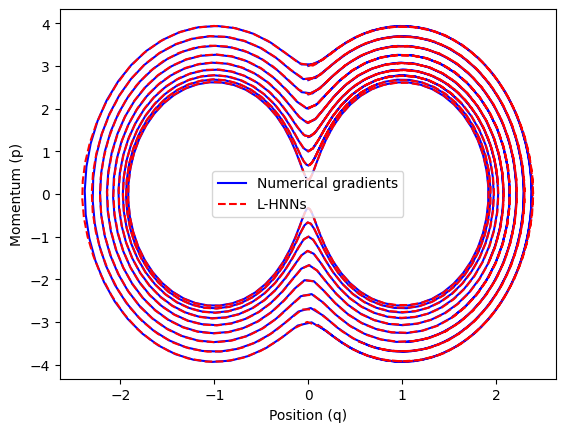

In [2]:
for idx, states in enumerate(states_numgrad):
    if idx == 0:
        plt.plot(states[:100,0], states[:100,1], color="blue", linestyle="-", label="Numerical gradients")
    else:
        plt.plot(states[:100,0], states[:100,1], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(states[:100,0], states[:100,1], color="red", linestyle="--", label="L-HNNs")
    else:
        plt.plot(states[:100,0], states[:100,1], color="red", linestyle="--")
plt.xlabel("Position (q)")
plt.ylabel("Momentum (p)")
plt.legend()
plt.show()

In [ ]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS
import mcmc

config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture.weights.h5")

hmc_lhnn = mcmc.HMC(initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, L=5, epsilon=0.05, hamiltonain_model=model, H_function=functions.functions("1D_Gauss_mix"),seed=config["seed"])
hmc_lhnn.sample()
hmc_numericalgrad = mcmc.HMC(initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, L=5, epsilon=0.05, hamiltonain_model=None, H_function=functions.functions("1D_Gauss_mix"),seed=config["seed"])
hmc_numericalgrad.sample()


Starting chain 1/1.


In [ ]:
plt.subplot(1,2,1)
plt.hist(hmc_numericalgrad.samples[:,:,hmc_numericalgrad.burnin:].flatten(), color="blue", bins=30, density=False)
plt.xlabel("Value")
plt.ylabel("Count")
plt.subplot(1,2,2)
plt.hist(hmc_lhnn.samples[:,:,hmc_lhnn.burnin:].flatten(), color="red", bins=30, density=False)
plt.xlabel("Value")
plt.ylabel("Count")

array([1.71644913, 1.03736321, 1.64785242, 0.5758752 , 0.91553988])

array([1.72727077, 1.06448722, 1.63935875, 0.58589548, 1.03017828])

In [33]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS

config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture.weights.h5")

initial_state = np.zeros(2)

timegrad_fn = utils.get_timegrad_fn(functions.functions("1D_Gauss_mix"))
states_lhnn = []
momentums = [2,-3]
for idx in range(2):
    initial_state[1] = momentums[idx]
    # states_numgrad.append(utils.get_trajectory(timegrad_fn, initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])
states_lhnn_reversed = []
for states in states_lhnn:
    initial_state = states[-1]
    # initial_state[1] = -initial_state[1]
    states_lhnn_reversed.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=-0.05, num_lf=100,require_grads=False)[0])


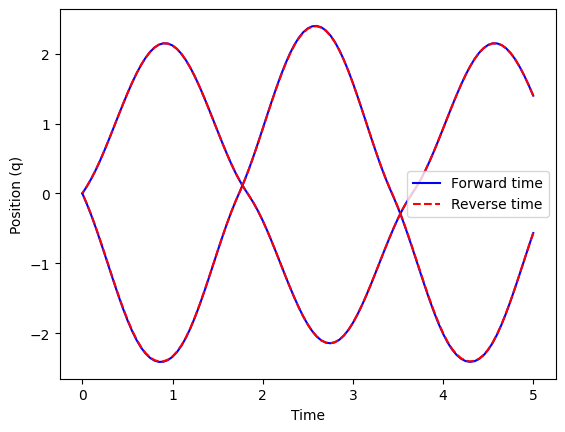

In [34]:
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), states[:,0], color="blue", linestyle="-", label="Forward time")
    else:
        plt.plot(np.linspace(0,5,101), states[:,0], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn_reversed):
    if idx == 0:
        plt.plot(np.linspace(0,5,101)[::-1], states[:,0], color="red", linestyle="--", label="Reverse time")
    else:
        plt.plot(np.linspace(0,5,101)[::-1], states[:,0], color="red", linestyle="--")

plt.xlabel("Time")
plt.ylabel("Position (q)")
plt.legend()
plt.show()

In [27]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS

config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture.weights.h5")

initial_state = np.zeros(2)
H_func = functions.functions("1D_Gauss_mix")
timegrad_fn = utils.get_timegrad_fn(H_func)
states_numgrad, states_lhnn = [], []
for idx in range(8):
    initial_state[1] = 1/3 * (idx+1)
    states_numgrad.append(utils.get_trajectory(timegrad_fn, initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])

H_numgrad, H_lhnn = [], []
for state_n, state_l in zip(states_numgrad, states_lhnn):
    H_numgrad.append(np.array([H_func(state) for state in state_n]))
    H_lhnn.append(np.array([H_func(state) for state in state_l]))

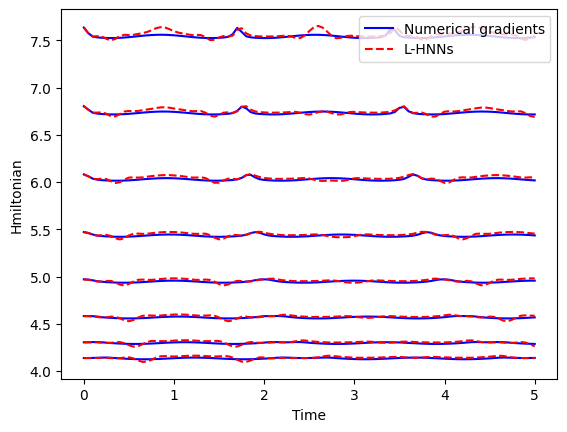

In [28]:
for idx, states in enumerate(states_numgrad):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), H_numgrad[idx], color="blue", linestyle="-", label="Numerical gradients")
    else:
        plt.plot(np.linspace(0,5,101), H_numgrad[idx], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), H_lhnn[idx], color="red", linestyle="--", label="L-HNNs")
    else:
        plt.plot(np.linspace(0,5,101), H_lhnn[idx], color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Hmiltonian")
plt.legend()
plt.show()

In [38]:
np.dot(H_numgrad[idx],H_numgrad[idx])

np.float64(1864.3751700423172)

In [66]:
int(np.random.choice([-1,1]))

1